# Machine Learning Models for GPA Prediction

##Machine Learning Models for Student Lifestyle(GPA prediction)
This section focuses on predicting students' GPAs using the Student Lifestyle dataset.

###Data Preparation

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_lifestyle = pd.read_csv("student_lifestyle_dataset.csv")

X_lifestyle = df_lifestyle.drop("GPA", axis=1)
y_lifestyle = df_lifestyle["GPA"]

X_train, X_test, y_train, y_test = train_test_split(
    X_lifestyle, y_lifestyle, test_size=0.2, random_state=42
)

X_lifestyle.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,Low
2,3,5.1,3.9,9.2,1.2,4.6,Low
3,4,6.5,2.1,7.2,1.7,6.5,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,High


In [26]:
X_lifestyle.dtypes

,0
Student_ID,int64
Study_Hours_Per_Day,float64
Extracurricular_Hours_Per_Day,float64
Sleep_Hours_Per_Day,float64
Social_Hours_Per_Day,float64
Physical_Activity_Hours_Per_Day,float64
Stress_Level,object


In [28]:
X_encoded = pd.get_dummies(X_lifestyle, drop_first=True)

X_encoded.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level_Low,Stress_Level_Moderate
0,1,6.9,3.8,8.7,2.8,1.8,False,True
1,2,5.3,3.5,8.0,4.2,3.0,True,False
2,3,5.1,3.9,9.2,1.2,4.6,True,False
3,4,6.5,2.1,7.2,1.7,6.5,False,True
4,5,8.1,0.6,6.5,2.2,6.6,False,False


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_lifestyle, test_size=0.2, random_state=42
)

## Model 1: Linear Regression
Linear Regression is used as a baseline model to evaluate the performance of a simple linear approach for GPA prediction.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.16436352885357836
MSE: 0.04225784325761663
R2 Score: 0.5473823980017121


## Linear Regression Results

The linear regression model achieved a moderate performance with an R² score of approximately 0.55.
This indicates that the model explains about 55% of the variance in GPA.

While the error values (MAE and MSE) are relatively low, the model is not sufficiently strong to fully capture the complexity of the data.

This suggests that linear models may be insufficient to fully capture the complex and potentially non-linear relationships present in behavioral data.

## Model 2: Random Forest Regression
Random Forest is a more advanced ensemble learning method that can capture non-linear relationships and interactions between variables.

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 0.17966300000000004
MSE: 0.05031883015000002
R2 Score: 0.4610423419149031


## Random Forest Results

The Random Forest model achieved a moderate performance with an R² score of approximately 0.46.  
This indicates that the model explains about 46% of the variance in GPA.

Compared to Linear Regression, the error values (MAE and MSE) are slightly higher, and the overall performance is lower.  
Although Random Forest is capable of capturing non-linear relationships, it did not improve the model performance in this case.

This suggests that the dataset may not contain strong non-linear patterns, and a more complex model does not necessarily lead to better results.

## Model 3: XGBoost Regression
XGBoost is an advanced gradient boosting algorithm designed for high performance and efficiency.
It builds models sequentially to correct the errors of previous models and is particularly effective for complex and non-linear datasets.

In [32]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

MAE: 0.19496293697357178
MSE: 0.060811955755094155
R2 Score: 0.3486520024484301


## XGBoost Results

The XGBoost model achieved a lower performance with an R² score of approximately 0.35.  
This indicates that the model explains about 35% of the variance in GPA.

The error values (MAE and MSE) are higher compared to both Linear Regression and Random Forest.  
Despite being a more advanced model, XGBoost did not perform well on this dataset.

This may be due to the relatively simple structure of the data or the limited number of features, which makes it difficult for complex models to generalize effectively.

### Model Comparison

The performance of three different models — Linear Regression, Random Forest, and XGBoost — was evaluated for GPA prediction.

Among these models, Linear Regression achieved the best performance with the highest R² score and the lowest error values.  
This indicates that it is the most suitable model for this dataset.

Random Forest showed moderate performance but did not outperform Linear Regression.  
Although it is capable of modeling non-linear relationships, it did not provide additional benefits in this case.

XGBoost, despite being a more advanced and powerful model, achieved the lowest performance among the three.  
This suggests that the dataset does not contain complex patterns that require advanced modeling techniques.

Overall, the results indicate that the relationships between the features and GPA are relatively simple and mostly linear.  
Therefore, a simpler model such as Linear Regression is sufficient and more effective for this dataset.

## Machine Learning Models for Student Performance (G3 Prediction)

This section focuses on predicting students' final grades (G3) using the Student Performance dataset.

### Data Preparation

Before training the models, the dataset is prepared by separating features and the target variable.
Categorical variables are converted into numerical format using one-hot encoding.

In [33]:
df_student = pd.read_csv("student-mat.csv", sep=";")

X_student= df_student.drop("G3", axis=1)
y_student = df_student["G3"]

X_encoded = pd.get_dummies(X_student, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_student, test_size=0.2, random_state=42
)

X_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


## Model 1: Linear Regression
Linear Regression is used as a baseline model to evaluate how well a simple linear approach can predict final grades.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.6466656197147511
MSE: 5.656642833231222
R2 Score: 0.7241341236974022


## Linear Regression Results

The Linear Regression model achieved a good performance with an R² score of approximately 0.72.  
This indicates that the model explains about 72% of the variance in final grades (G3).

However, its error values are higher compared to the other models, suggesting that a simple linear approach may not fully capture the relationships in this dataset.

## Model 2: Random Forest Regression
Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction performance and capture non-linear relationships.

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 1.1645569620253164
MSE: 3.797716455696203
R2 Score: 0.8147911386865877


## Random Forest Results

The Random Forest model achieved the best performance with an R² score of approximately 0.81.  
This indicates that the model explains about 81% of the variance in final grades (G3).

It also produced the lowest MAE and MSE values among the three models.  
This suggests that Random Forest is better at capturing the relationships between academic, demographic, and behavioral variables in this dataset.

## Model 3: XGBoost Regression
XGBoost is a powerful gradient boosting algorithm that builds models sequentially and is effective for capturing complex patterns in data.

In [36]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

MAE: 1.1961461305618286
MSE: 4.551809310913086
R2 Score: 0.7780151963233948


## XGBoost Results

The XGBoost model achieved a strong performance with an R² score of approximately 0.78.  
This indicates that the model explains about 78% of the variance in final grades (G3).

Although XGBoost performed better than Linear Regression, it did not outperform Random Forest in this dataset.

## Model Comparison

The performance of Linear Regression, Random Forest, and XGBoost models was evaluated for predicting students' final grades (G3).

Among these models, Random Forest achieved the best performance with the highest R² score and the lowest error values.  
This indicates that it is the most suitable model for this dataset.

Linear Regression showed moderate performance, suggesting that while some relationships are linear, they are not sufficient to fully explain the data.

XGBoost performed well but did not surpass Random Forest.  
Although it is a powerful model, it did not provide a significant improvement in this case.

Overall, the results suggest that the relationships in this dataset are more complex and include non-linear patterns, which are better captured by ensemble models such as Random Forest.

#Feature Importance

## Feature Importance for Lifestyle Dataset

Feature importance is examined using the Random Forest model to understand which variables contribute most to GPA prediction.

In [37]:
df = pd.read_csv("student_lifestyle_dataset.csv")

X_lifestyle = df.drop("GPA", axis=1)
y_lifestyle = df["GPA"]

X_lifestyle_encoded = pd.get_dummies(X_lifestyle, drop_first=True)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train_lifestyle, X_test_lifestyle, y_train_lifestyle, y_test_lifestyle = train_test_split(
    X_lifestyle_encoded,
    y_lifestyle,
    test_size=0.2,
    random_state=42
)

rf_lifestyle = RandomForestRegressor(random_state=42)
rf_lifestyle.fit(X_train_lifestyle, y_train_lifestyle)

feature_importances_lifestyle = pd.Series(
    rf_lifestyle.feature_importances_,
    index=X_train_lifestyle.columns
)

feature_importances_lifestyle.sort_values(ascending=False).head(10)

,0
Study_Hours_Per_Day,0.584368
Student_ID,0.102254
Physical_Activity_Hours_Per_Day,0.079139
Social_Hours_Per_Day,0.078947
Extracurricular_Hours_Per_Day,0.077527
Sleep_Hours_Per_Day,0.073471
Stress_Level_Moderate,0.003418
Stress_Level_Low,0.000877


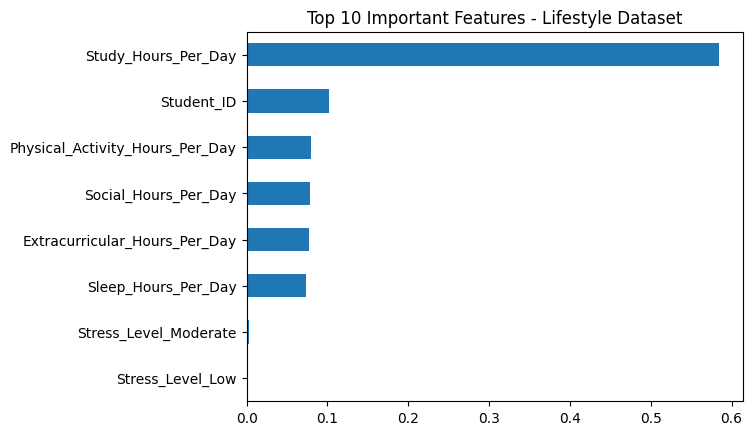

In [38]:
import matplotlib.pyplot as plt

feature_importances_lifestyle.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Important Features - Lifestyle Dataset")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance for Student Performance Dataset

Feature importance is examined using the Random Forest model, which achieved the best performance for G3 prediction.

In [39]:
import pandas as pd

feature_importances = pd.Series(rf.feature_importances_, index=X_encoded.columns)
feature_importances.sort_values(ascending=False).head(10)

,0
G2,0.793254
absences,0.110093
reason_home,0.021086
age,0.010433
G1,0.005979
famrel,0.005260
goout,0.004840
health,0.004190
activities_yes,0.003933
studytime,0.003697


## Feature Importance Result

This feature importance analysis supports the model comparison results by showing which variables are most influential in predicting final grades. Since Random Forest performed best on this dataset, its feature importance values are useful for interpreting the model.

## Final Insights Across Both Datasets

The results from the two datasets reveal important differences in the nature of academic performance.

In the Student Lifestyle dataset, Linear Regression performed best, indicating that GPA is largely influenced by relatively simple and linear relationships such as study hours and stress level.

In contrast, in the Student Performance dataset, Random Forest achieved the best results, suggesting that predicting final grades (G3) requires capturing more complex and non-linear relationships between variables such as academic history, behavior, and demographic factors.

These findings demonstrate that the choice of model depends heavily on the structure of the data.  
While simpler models may be sufficient for datasets with clear linear relationships, more advanced models are needed when the data contains more complex patterns.

Overall, this highlights the importance of selecting appropriate models based on the characteristics of the dataset rather than assuming that more complex models will always perform better.